# Clinical Outcome Prediction from Noisy Medical Records

Machine Learning Project

In this project we work with a real dataset of diabetic patients from 130 US hospitals (1999–2008).
Our goal is to clean the data, explore it, and build a machine learning model that predicts whether a patient will be readmitted to the hospital.


---

**Table of Contents:**

1. Data Loading & Preparation
2. Dataset Understanding
3. Initial Data Exploration
4. Exploratory Data Analysis (EDA)
5. Data Cleaning & Missing Values Handling
6. Target Variable Definition
7. Categorical Feature Encoding
8. Feature Selection & Ranking
9. Feature Scaling
10. Dimensionality Reduction (PCA)
11. Adversarial Label Noise Injection
12. Machine Learning Model Training & Evaluation
13. Final Results & Best Model Selection


---
## 1. Imports & Load Data

In [5]:
# Import all the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

print('Libraries imported successfully!')

Libraries imported successfully!


In [6]:
# Load the dataset
# In Google Colab, upload the file first:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('diabetic_data.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Dataset loaded: 101,766 rows, 50 columns


## 2. Dataset Understanding

Before preprocessing, we first examined the dataset structure and understood the meaning of each feature.

The Diabetes 130-US Hospitals dataset contains 101,766 patient records and 50 features collected from 130 hospitals in the United States.

The features are grouped into the following categories:

| Group | Features | Count |
|---|---|---:|
| Identifiers | encounter_id, patient_nbr | 2 |
| Demographics | race, gender, age, weight | 4 |
| Hospital Information | admission_type_id, discharge_disposition_id, admission_source_id, time_in_hospital, payer_code, medical_specialty | 6 |
| Clinical Numbers | num_lab_procedures, num_procedures, num_medications, number_outpatient, number_emergency, number_inpatient, number_diagnoses | 7 |
| Diagnosis Codes | diag_1, diag_2, diag_3 | 3 |
| Lab Results | max_glu_serum, A1Cresult | 2 |
| Medications | metformin, insulin, glipizide and other diabetes medications | 23 |
| Target Variable | readmitted | 1 |

### Target Variable: readmitted

The original target column contains three classes:

- **NO** → the patient was not readmitted
- **>30** → the patient was readmitted after more than 30 days
- **<30** → the patient was readmitted within 30 days

For this project, the problem was converted into binary classification:

- **0 = Not readmitted within 30 days**
- **1 = Readmitted within 30 days (<30)**

The positive class is **<30** because readmission within 30 days is the most clinically important outcome and has the highest impact on hospital quality and patient care.

---
## 3. Initial Overview

In [7]:
# Basic info about the dataset
print('Shape:', df.shape)
print()
print('Column types:')
print(df.dtypes.value_counts())
print()
print('First 5 rows:')
df.head()

Shape: (101766, 50)

Column types:
object    37
int64     13
Name: count, dtype: int64

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
# Check for missing values
# In this dataset, missing values are written as '?' not NaN
# So we replace '?' with NaN first
df_check = df.replace('?', np.nan)

missing = df_check.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
result = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
result = result[result['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with missing values:')
print(result)

Columns with missing values:
                   Missing Count  Missing %
weight                     98569       96.9
max_glu_serum              96420       94.7
A1Cresult                  84748       83.3
medical_specialty          49949       49.1
payer_code                 40256       39.6
race                        2273        2.2
diag_3                      1423        1.4
diag_2                       358        0.4
diag_1                        21        0.0


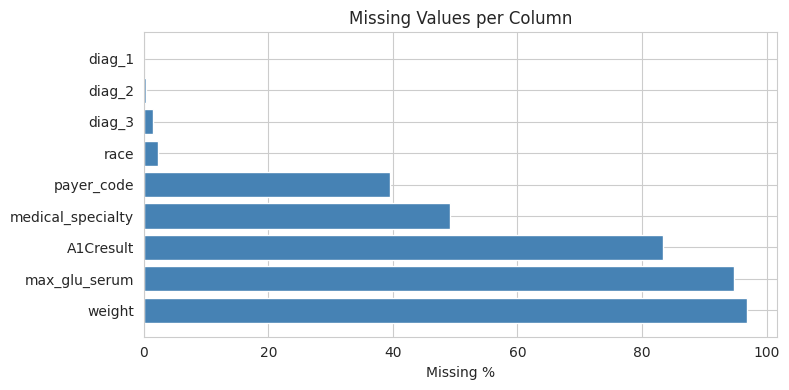


Decision:
- weight is 97% missing → we will DROP it (cannot impute)
- max_glu_serum and A1Cresult are >80% missing → keep as category (missing = test not done)
- race, payer_code, medical_specialty → fill with Unknown


In [9]:
# Visualize missing values
plt.figure(figsize=(8, 4))
plt.barh(result.index, result['Missing %'], color='steelblue')
plt.xlabel('Missing %')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()

print('\nDecision:')
print('- weight is 97% missing → we will DROP it (cannot impute)')
print('- max_glu_serum and A1Cresult are >80% missing → keep as category (missing = test not done)')
print('- race, payer_code, medical_specialty → fill with Unknown')

---
## 4. Exploratory Data Analysis (EDA)

EDA means we look at the data carefully before cleaning or modeling.
Every decision we make later must be based on what we see here — not random choices.

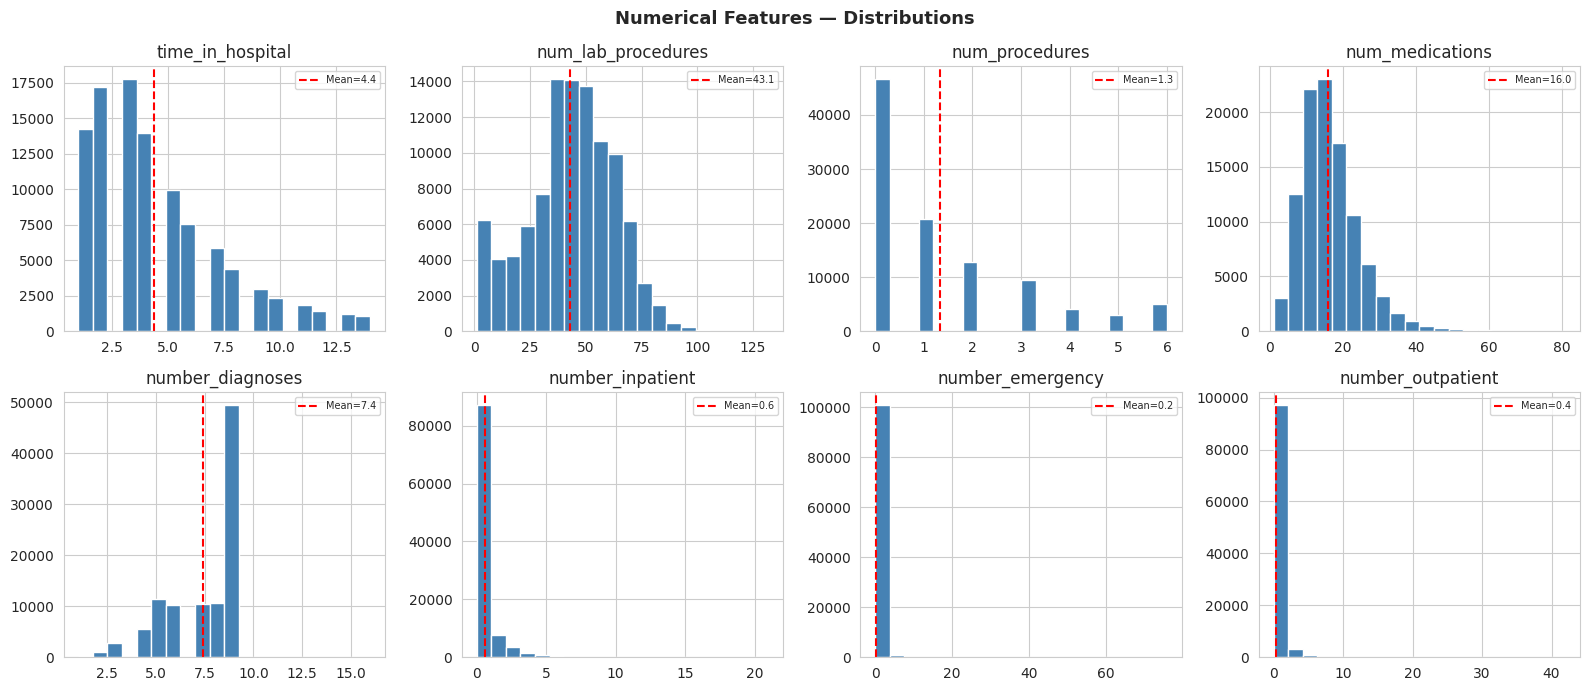

In [10]:
# --- 4.2 Numerical Features: Histograms ---
# We look at how numerical features are distributed

num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_diagnoses', 'number_inpatient',
            'number_emergency', 'number_outpatient']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.1f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Numerical Features — Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

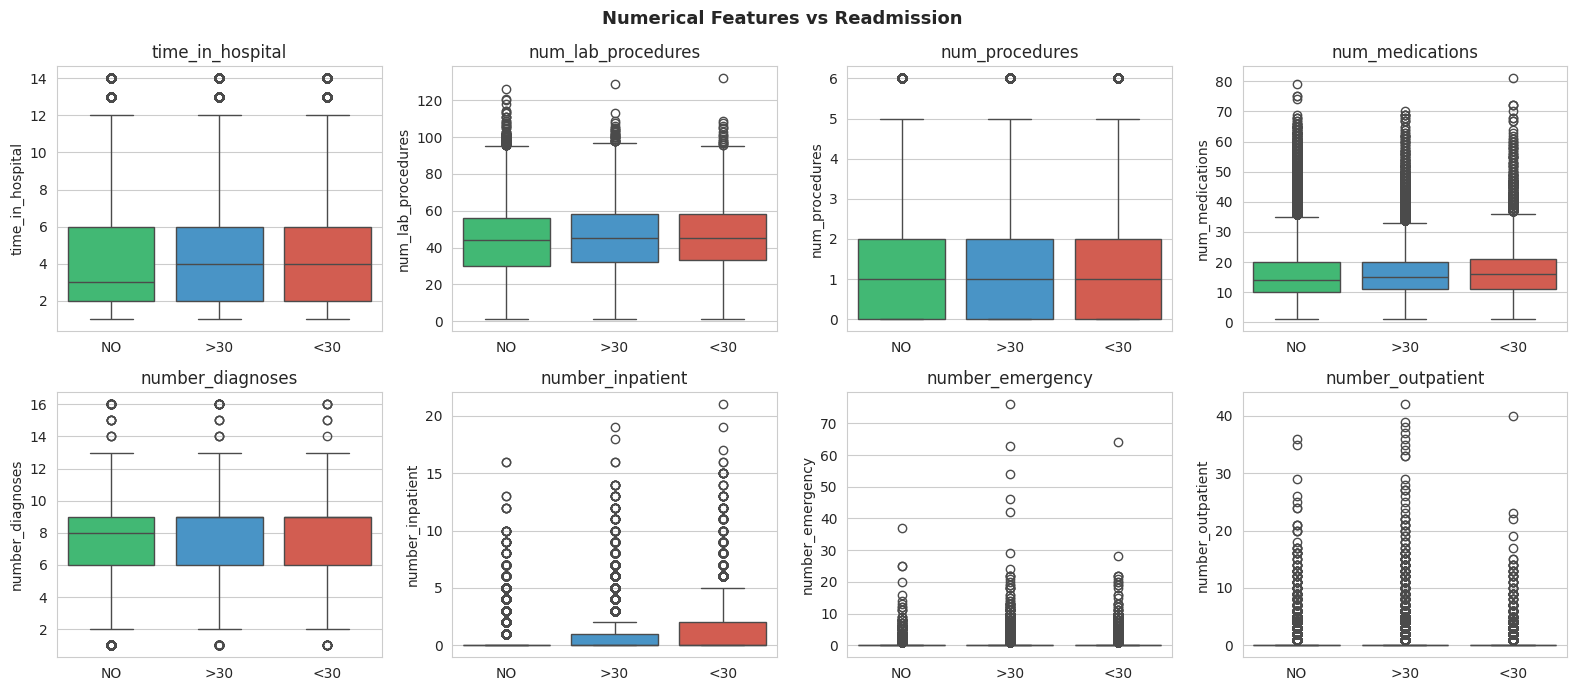

Insight:
  - number_inpatient: clearly higher for readmitted patients → strong predictor
  - time_in_hospital: slightly higher for readmitted → useful
  - number_outpatient: almost same across classes → weaker predictor


In [11]:
# --- 4.3 Numerical Features vs Target: Boxplots ---
# This shows if a feature is different across readmission classes
# Features with different boxes = more useful for prediction

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

order = ['NO', '>30', '<30']
palette = {'NO': '#2ecc71', '>30': '#3498db', '<30': '#e74c3c'}

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='readmitted', y=col,
                order=order, palette=palette, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Numerical Features vs Readmission', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight:')
print('  - number_inpatient: clearly higher for readmitted patients → strong predictor')
print('  - time_in_hospital: slightly higher for readmitted → useful')
print('  - number_outpatient: almost same across classes → weaker predictor')

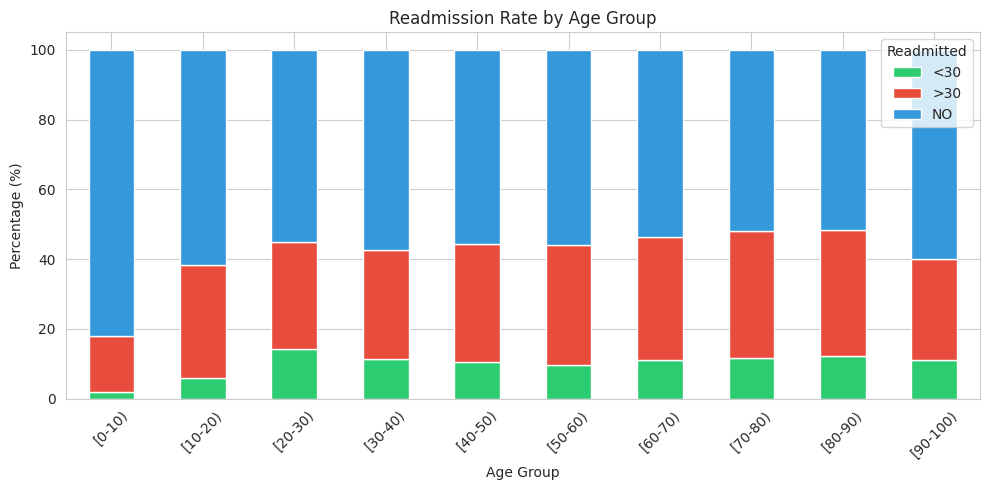

Insight: Older patients (60-90) have higher readmission rates.
This justifies encoding age as ORDINAL (0-10), not one-hot encoding.


In [12]:
# --- 4.4 Age vs Readmission ---
# We want to know: do older patients get readmitted more?

age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_readmit = pd.crosstab(df['age'], df['readmitted'], normalize='index') * 100
age_readmit = age_readmit.reindex(age_order)

age_readmit.plot(kind='bar', stacked=True,
                 color=['#2ecc71', '#e74c3c', '#3498db'],
                 figsize=(10, 5), edgecolor='white')
plt.title('Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Readmitted')
plt.tight_layout()
plt.show()

print('Insight: Older patients (60-90) have higher readmission rates.')
print('This justifies encoding age as ORDINAL (0-10), not one-hot encoding.')

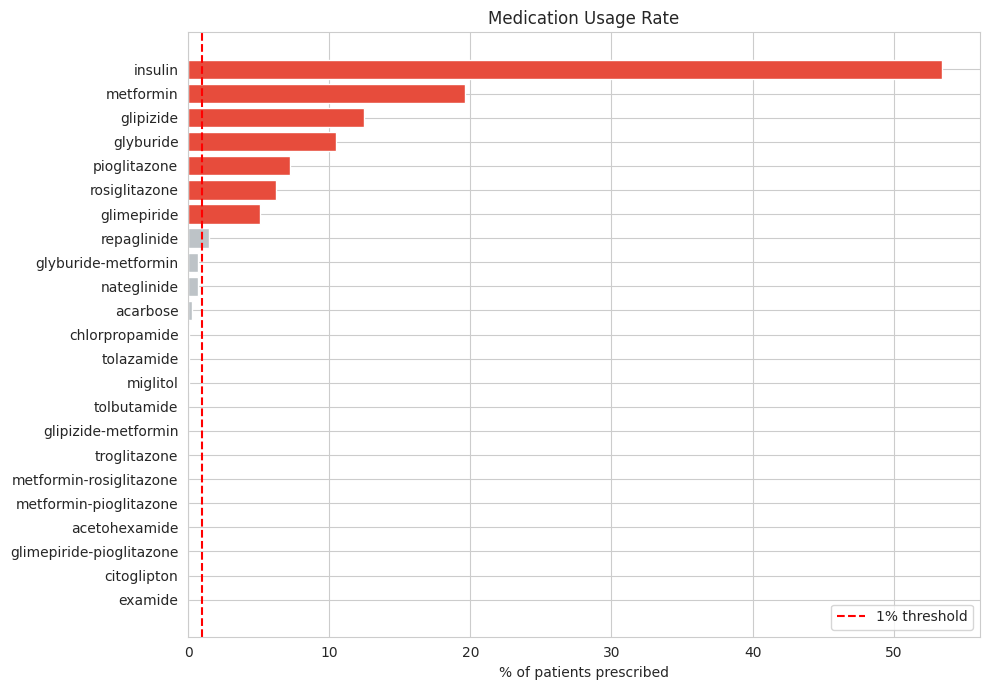

Medications with < 1% usage (will be removed): ['examide', 'citoglipton', 'glimepiride-pioglitazone', 'acetohexamide', 'metformin-pioglitazone', 'metformin-rosiglitazone', 'troglitazone', 'glipizide-metformin', 'tolbutamide', 'miglitol', 'tolazamide', 'chlorpropamide', 'acarbose', 'nateglinide', 'glyburide-metformin']


In [13]:
# --- 4.5 Medication Columns: How many are actually used? ---
# There are 23 medication columns. Most patients are on 'No' (not prescribed).
# Columns where almost everyone has 'No' = useless for prediction.

med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
            'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

# Calculate how many patients actually use each medication (not 'No')
usage = {col: (df[col] != 'No').sum() / len(df) * 100 for col in med_cols}
usage_series = pd.Series(usage).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors_bar = ['#e74c3c' if v > 5 else '#bdc3c7' for v in usage_series.values]
plt.barh(usage_series.index, usage_series.values, color=colors_bar)
plt.axvline(x=1, color='red', linestyle='--', label='1% threshold')
plt.xlabel('% of patients prescribed')
plt.title('Medication Usage Rate')
plt.legend()
plt.tight_layout()
plt.show()

low_use = usage_series[usage_series < 1].index.tolist()
print(f'Medications with < 1% usage (will be removed): {low_use}')

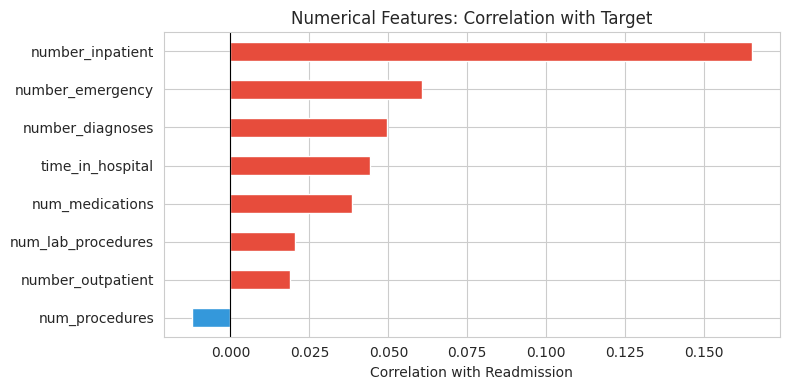

Insight:
Positive = higher value → more likely to be readmitted
number_inpatient has the strongest positive correlation


In [14]:
# --- 4.6 Correlation between numerical features and target ---
# We create a temporary binary target to measure correlations

df_temp = df.copy()
df_temp['target'] = (df_temp['readmitted'] == '<30').astype(int)

corr_values = df_temp[num_cols + ['target']].corr()['target'].drop('target').sort_values()

plt.figure(figsize=(8, 4))
corr_values.plot(kind='barh',
                 color=['#e74c3c' if v > 0 else '#3498db' for v in corr_values])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with Readmission')
plt.title('Numerical Features: Correlation with Target')
plt.tight_layout()
plt.show()

print('Insight:')
print('Positive = higher value → more likely to be readmitted')
print('number_inpatient has the strongest positive correlation')

---
## 5. Data Cleaning

Now we clean the data based on what we found in EDA.
Every step has a clear reason — nothing is random.

In [15]:
# Start with a clean copy
df_clean = df.copy()

# Step 1: Replace '?' with NaN
df_clean.replace('?', np.nan, inplace=True)
print('Step 1 done: replaced ? with NaN')

Step 1 done: replaced ? with NaN


In [16]:
# Step 2: Handle duplicate patients
# The same patient can appear multiple times (multiple hospital visits)
# We keep only the FIRST visit to avoid data leakage
print(f'Total records: {len(df_clean):,}')
print(f'Unique patients: {df_clean["patient_nbr"].nunique():,}')

df_clean = df_clean.drop_duplicates(subset='patient_nbr', keep='first')
print(f'After keeping first visit per patient: {len(df_clean):,}')

Total records: 101,766
Unique patients: 71,518
After keeping first visit per patient: 71,518


In [17]:
# Step 3: Drop identifier columns (no predictive value)
df_clean.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)
print('Dropped identifier columns: encounter_id, patient_nbr')

Dropped identifier columns: encounter_id, patient_nbr


In [18]:
# Step 4: Drop 'weight' column
# Reason: 97% missing. Impossible to impute reliably.
df_clean.drop('weight', axis=1, inplace=True)
print('Dropped: weight (97% missing)')

Dropped: weight (97% missing)


In [19]:
# Step 5: Handle lab result columns
# Instead of dropping them (clinically important!),
# we fill NaN with 'None' — meaning the test was never done.
# 'Test not done' is itself a useful medical signal.
for col in ['max_glu_serum', 'A1Cresult']:
    df_clean[col] = df_clean[col].fillna('None')
print('max_glu_serum and A1Cresult: NaN → None')

max_glu_serum and A1Cresult: NaN → None


In [20]:
# Step 6: Fill missing values in other categorical columns
for col in ['race', 'payer_code', 'medical_specialty']:
    df_clean[col] = df_clean[col].fillna('Unknown')
print('race, payer_code, medical_specialty: NaN → Unknown')

race, payer_code, medical_specialty: NaN → Unknown


In [21]:
# Step 7: Remove zero-variance features
# These are columns where ALL values are the same → useless for prediction
zero_var = [col for col in df_clean.columns if df_clean[col].nunique() <= 1]
print(f'Zero-variance columns found: {zero_var}')
if zero_var:
    df_clean.drop(zero_var, axis=1, inplace=True)
    print(f'Dropped {len(zero_var)} zero-variance columns')

Zero-variance columns found: ['examide', 'citoglipton', 'glimepiride-pioglitazone']
Dropped 3 zero-variance columns


In [22]:
# Step 8: Remove near-zero-variance medication columns (<1% usage)
low_use_meds = [col for col in med_cols
                if col in df_clean.columns
                and (df_clean[col] != 'No').sum() / len(df_clean) < 0.01]
df_clean.drop(low_use_meds, axis=1, inplace=True)
print(f'Dropped {len(low_use_meds)} near-zero medication columns: {low_use_meds}')

Dropped 12 near-zero medication columns: ['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin', 'glipizide-metformin', 'metformin-rosiglitazone', 'metformin-pioglitazone']


In [23]:
# Step 9: Remove rows with invalid gender
df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid']
print('Removed rows with invalid gender')

# Step 10: Remove patients who died (discharge_disposition = 11,13,14,19,20,21)
# These patients cannot be readmitted — including them would confuse the model
dead_codes = [11, 13, 14, 19, 20, 21]
df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(dead_codes)]
print('Removed patients who died or went to hospice')

print(f'\nFinal cleaned shape: {df_clean.shape}')

Removed rows with invalid gender
Removed patients who died or went to hospice

Final cleaned shape: (69970, 32)


---
## 6. Target Variable Setup

In [24]:
print(df_clean.columns.tolist())

['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted']


In [25]:
# Create binary target
# 1 = readmitted within 30 days (<30)
# 0 = otherwise (NO or >30)

df_clean['readmitted_binary'] = (df_clean['readmitted'] == '<30').astype(int)

print('Target distribution:')
print(df_clean['readmitted_binary'].value_counts())
print()
print('0 = Not readmitted within 30 days')
print('1 = Readmitted within 30 days (<30)')

# Save target and drop original columns
y = df_clean['readmitted_binary'].copy()
df_clean.drop(['readmitted', 'readmitted_binary'], axis=1, inplace=True)

Target distribution:
readmitted_binary
0    63693
1     6277
Name: count, dtype: int64

0 = Not readmitted within 30 days
1 = Readmitted within 30 days (<30)


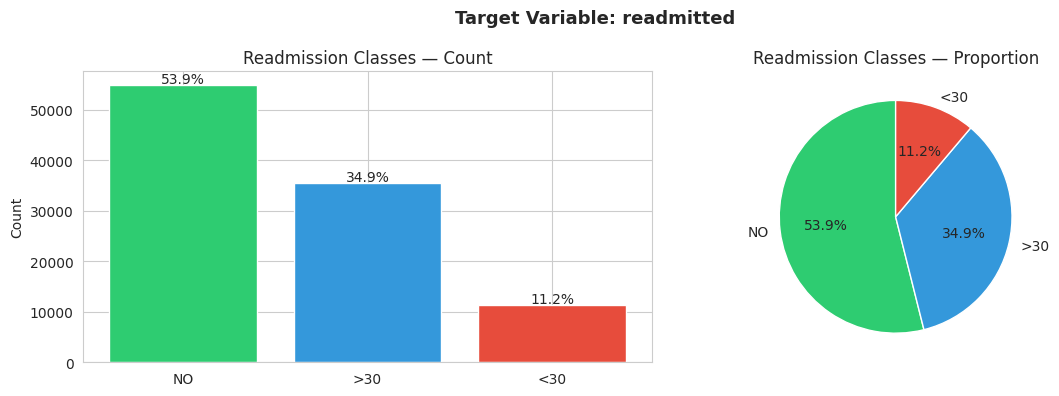

Insight: The data is IMBALANCED.
  NO (not readmitted):  53.9%
  >30 (after 30 days):  34.9%
  <30 (within 30 days): 11.2%

Decision: We will use <30 as the positive class.
Binary classification: 0 = Not readmitted within 30 days, 1 = Readmitted within 30 days


In [26]:
# --- 4.1 Target Variable Distribution ---
# The most important thing to analyze first is our target variable

target_counts = df['readmitted'].value_counts()
target_pct = (target_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = {'NO': '#2ecc71', '>30': '#3498db', '<30': '#e74c3c'}
axes[0].bar(target_counts.index,
            target_counts.values,
            color=[colors[c] for c in target_counts.index])
axes[0].set_title('Readmission Classes — Count')
axes[0].set_ylabel('Count')
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + 400, f'{p}%', ha='center', fontsize=10)

# Pie chart
axes[1].pie(target_counts.values,
            labels=target_counts.index,
            colors=[colors[c] for c in target_counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Readmission Classes — Proportion')

plt.suptitle('Target Variable: readmitted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: The data is IMBALANCED.')
print(f'  NO (not readmitted):  {target_pct["NO"]}%')
print(f'  >30 (after 30 days):  {target_pct[">30"]}%')
print(f'  <30 (within 30 days): {target_pct["<30"]}%')
print()
print('Decision: We will use <30 as the positive class.')
print('Binary classification: 0 = Not readmitted within 30 days, 1 = Readmitted within 30 days')

---
## 7. Encoding Categorical Features

Machine learning models only understand numbers, not text.
We need to convert all text columns to numbers.

In [27]:
# Age → Ordinal encoding (1 to 10)
# We use ordinal because age has a natural order: older = higher number
age_map = {
    '[0-10)': 1, '[10-20)': 2, '[20-30)': 3, '[30-40)': 4, '[40-50)': 5,
    '[50-60)': 6, '[60-70)': 7, '[70-80)': 8, '[80-90)': 9, '[90-100)': 10
}
df_clean['age'] = df_clean['age'].map(age_map)
print('Age encoded as 1-10')

Age encoded as 1-10


In [28]:
# Medication columns → Ordinal encoding (0 to 3)
# No=0, Steady=1, Down=2, Up=3
# This captures the intensity of medication usage
med_encode = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

current_meds = [col for col in med_cols
                if col in df_clean.columns
                and df_clean[col].dtype == object]

for col in current_meds:
    df_clean[col] = df_clean[col].map(med_encode).fillna(0).astype(int)

print(f'Encoded {len(current_meds)} medication columns: No=0, Steady=1, Down=2, Up=3')

Encoded 8 medication columns: No=0, Steady=1, Down=2, Up=3


In [29]:
# Binary columns
if 'gender' in df_clean.columns:
    df_clean['gender'] = (df_clean['gender'] == 'Male').astype(int)
if 'change' in df_clean.columns:
    df_clean['change'] = (df_clean['change'] == 'Ch').astype(int)
if 'diabetesMed' in df_clean.columns:
    df_clean['diabetesMed'] = (df_clean['diabetesMed'] == 'Yes').astype(int)
print('Binary columns encoded: gender, change, diabetesMed')

Binary columns encoded: gender, change, diabetesMed


In [30]:
# Reduce cardinality of high-cardinality columns before OHE
# medical_specialty has too many values — keep only top 5
if 'medical_specialty' in df_clean.columns:
    top5 = df_clean['medical_specialty'].value_counts().nlargest(5).index
    df_clean['medical_specialty'] = df_clean['medical_specialty'].apply(
        lambda x: x if x in top5 else 'Other'
    )

# diag_1/2/3: Group ICD codes into disease categories
def simplify_diag(code):
    if pd.isna(code): return 'Unknown'
    code = str(code)
    if code.startswith('V') or code.startswith('E'): return 'Other'
    try:
        n = float(code.split('.')[0])
    except:
        return 'Unknown'
    if 390 <= n <= 459: return 'Circulatory'
    if 460 <= n <= 519: return 'Respiratory'
    if 520 <= n <= 579: return 'Digestive'
    if n == 250: return 'Diabetes'
    if 800 <= n <= 999: return 'Injury'
    if 140 <= n <= 239: return 'Neoplasms'
    return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(simplify_diag)
print('Diagnosis codes grouped into disease categories')

Diagnosis codes grouped into disease categories


In [31]:
# One-Hot Encoding for remaining text columns
remaining_cat = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Columns to one-hot encode: {remaining_cat}')

df_encoded = pd.get_dummies(df_clean, columns=remaining_cat, drop_first=True)
print(f'\nAfter encoding: {df_encoded.shape[0]:,} rows × {df_encoded.shape[1]} columns')

Columns to one-hot encode: ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult']

After encoding: 69,970 rows × 77 columns


---
## 8. Feature Ranking

We use Random Forest to find out which features are most useful.
This helps us remove noisy/unimportant features before building the model.

**Important:** We rank ALL features, not just the numerical ones.

In [32]:
X_all = df_encoded.copy()
y_all = y.reindex(X_all.index)

# Train a simple Random Forest to get feature importance
print('Training Random Forest for feature ranking...')
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,           # Keep it simple
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_all, y_all)

# Get and sort feature importances
importance_df = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 20 features:')
print(importance_df.head(20).to_string())

Training Random Forest for feature ranking...
Top 20 features:
                     Feature  Importance
0   discharge_disposition_id    0.205475
1           number_inpatient    0.133292
2           time_in_hospital    0.072674
3                        age    0.057195
4         num_lab_procedures    0.056723
5            num_medications    0.050433
6           number_diagnoses    0.046195
7             num_procedures    0.020937
8           number_emergency    0.020137
9                    insulin    0.016761
10         admission_type_id    0.015827
11               diabetesMed    0.015532
12       admission_source_id    0.014825
13        payer_code_Unknown    0.014180
14         number_outpatient    0.013725
15                 metformin    0.010001
16              diag_1_Other    0.009571
17          diag_2_Neoplasms    0.007697
18             payer_code_MC    0.007611
19                    change    0.007166


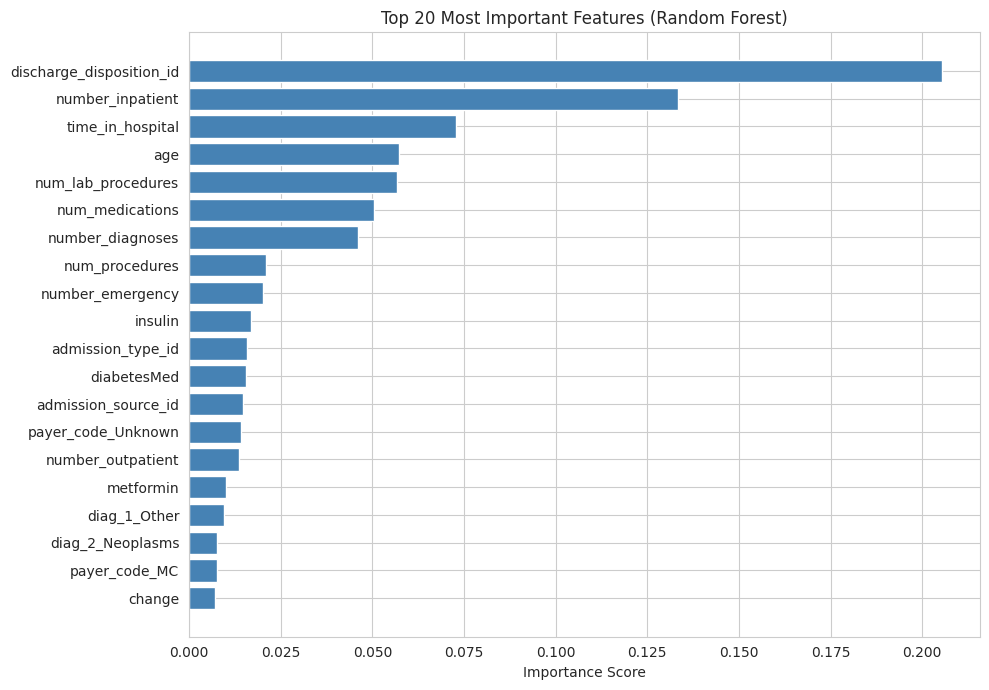


Selected top 29 features (cover 85% of importance)


In [33]:
# Plot top 20 features
plt.figure(figsize=(10, 7))
top20 = importance_df.head(20)
plt.barh(top20['Feature'][::-1], top20['Importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 20 Most Important Features (Random Forest)')
plt.tight_layout()
plt.show()

# Select features that cover 85% of total importance
cumsum = importance_df['Importance'].cumsum()
n_features = (cumsum < 0.85).sum() + 1
selected_features = importance_df.head(n_features)['Feature'].tolist()
print(f'\nSelected top {n_features} features (cover 85% of importance)')

X_selected = X_all[selected_features]

---
## 9. Feature Scaling

StandardScaler transforms all features to have mean=0 and std=1.
This is required before PCA because PCA is sensitive to the scale of features.

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

print(f'Scaled {X_selected.shape[1]} features')
print(f'Mean (should be ≈0): {X_scaled.mean():.4f}')
print(f'Std  (should be ≈1): {X_scaled.std():.4f}')

Scaled 29 features
Mean (should be ≈0): -0.0000
Std  (should be ≈1): 1.0000


---
## 10. Dimensionality Reduction (PCA)

PCA reduces the number of features while keeping most of the information.
We apply it AFTER feature ranking — not before (common mistake).

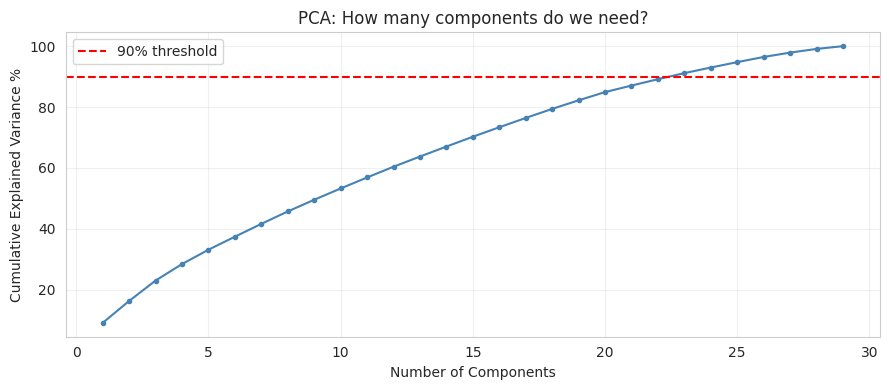

We need 23 components to explain 90% of the variance


In [59]:
# Run PCA and plot explained variance
pca_check = PCA(random_state=42)
pca_check.fit(X_scaled)

cumulative_var = np.cumsum(pca_check.explained_variance_ratio_) * 100

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', markersize=3, color='steelblue')
plt.axhline(y=90, color='red', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance %')
plt.title('PCA: How many components do we need?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find how many components explain 90% of variance
n_comp = int(np.argmax(cumulative_var >= 90)) + 1
print(f'We need {n_comp} components to explain 90% of the variance')

In [69]:
# Apply PCA with the chosen number of components
pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA result: {X_scaled.shape[1]} features → {n_comp} components')
print(f'Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

print(X_pca.shape[1])

PCA result: 29 features → 23 components
Variance retained: 91.1%
23


---
## 11. Adversarial Condition — Label Noise

In real medical data, records contain errors (wrong diagnosis, wrong readmission status).
We simulate this by randomly flipping 10% of labels.

In [37]:
np.random.seed(42)
n_flip = int(0.10 * len(y_all))
flip_idx = np.random.choice(len(y_all), n_flip, replace=False)

y_noisy = y_all.copy()
y_noisy.iloc[flip_idx] = 1 - y_noisy.iloc[flip_idx]

print(f'Flipped {n_flip:,} labels (10%)')
print(f'Original: {y_all.value_counts().to_dict()}')
print(f'Noisy:    {y_noisy.value_counts().to_dict()}')
print()
print('y_all   = clean labels (use for normal training)')
print('y_noisy = noisy labels (use to test model robustness)')

Flipped 6,997 labels (10%)
Original: {0: 63693, 1: 6277}
Noisy:    {0: 57938, 1: 12032}

y_all   = clean labels (use for normal training)
y_noisy = noisy labels (use to test model robustness)


## 12. Stage 2 — Machine Learning Models

In this stage, we trained and compared multiple machine learning models to identify the best model for predicting hospital readmission.

The following baseline classifiers were used:

1. **Logistic Regression** — simple, interpretable, and strong baseline for imbalanced medical data  
2. **Decision Tree** — easy to understand and visualize  
3. **Random Forest** — ensemble model with stronger predictive performance  
4. **Naive Bayes** — fast probabilistic classifier  
5. **K-Nearest Neighbors (KNN)** — distance-based classification model  
6. **Support Vector Machine (SVM)** — effective for high-dimensional classification tasks  
7. **Gradient Boosting** — strong boosting model for improved prediction performance

Each model was evaluated using:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- AUC-ROC  
- Confusion Matrix  
- ROC Curves  
- Cross-Validation

Because the dataset is highly imbalanced, Accuracy alone was not enough. Greater focus was given to Recall, F1-score, and AUC-ROC, especially for detecting the minority class (patients readmitted within 30 days).

After comparing all models, Logistic Regression, Random Forest, and SVM were selected as the strongest models for further hyperparameter tuning. Logistic Regression was finally chosen as the best overall model because it achieved the best balance between AUC, Recall, interpretability, and minority class detection.

In [38]:
# Split the data into Train / Validation / Test sets
# 70% Train, 15% Validation, 15% Test

X_train, X_temp, y_train, y_temp = train_test_split(
    X_pca,
    y_all,
    test_size=0.30,
    random_state=42,
    stratify=y_all
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f'Training set:   {X_train.shape[0]:,} samples')
print(f'Validation set: {X_val.shape[0]:,} samples')
print(f'Test set:       {X_test.shape[0]:,} samples')

print()
print('Class distribution in training:')
print(pd.Series(y_train).value_counts())

Training set:   48,979 samples
Validation set: 10,495 samples
Test set:       10,496 samples

Class distribution in training:
readmitted_binary
0    44585
1     4394
Name: count, dtype: int64


In [39]:
# --- Model 1: Logistic Regression ---
# A simple linear model. Good as a baseline.

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_val)
lr_prob = lr_model.predict_proba(X_val)[:, 1]

print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_val, lr_pred):.3f}')
print(f'AUC Score: {roc_auc_score(y_val, lr_prob):.3f}')
print()
print(classification_report(y_val, lr_pred, target_names=['Not Readmitted', 'Readmitted']))

=== Logistic Regression ===
Accuracy: 0.636
AUC Score: 0.621

                precision    recall  f1-score   support

Not Readmitted       0.93      0.65      0.76      9554
    Readmitted       0.13      0.52      0.20       941

      accuracy                           0.64     10495
     macro avg       0.53      0.58      0.48     10495
  weighted avg       0.86      0.64      0.71     10495



In [40]:
# --- Model 2: Decision Tree ---
# A model that makes decisions based on simple if/else rules.
# Easy to understand and visualize.

dt_model = DecisionTreeClassifier(
    max_depth=6,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_val)
dt_prob = dt_model.predict_proba(X_val)[:, 1]

print('=== Decision Tree ===')
print(f'Accuracy: {accuracy_score(y_val, dt_pred):.3f}')
print(f'AUC Score: {roc_auc_score(y_val, dt_prob):.3f}')
print()
print(classification_report(y_val, dt_pred, target_names=['Not Readmitted', 'Readmitted']))

=== Decision Tree ===
Accuracy: 0.490
AUC Score: 0.592

                precision    recall  f1-score   support

Not Readmitted       0.94      0.47      0.63      9554
    Readmitted       0.11      0.67      0.19       941

      accuracy                           0.49     10495
     macro avg       0.52      0.57      0.41     10495
  weighted avg       0.86      0.49      0.59     10495



In [41]:
# --- Model 3: Random Forest ---
# An ensemble of many decision trees. Usually the most accurate.

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)
rf_prob = rf_model.predict_proba(X_val)[:, 1]

print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_val, rf_pred):.3f}')
print(f'AUC Score: {roc_auc_score(y_val, rf_prob):.3f}')
print()
print(classification_report(y_val, rf_pred, target_names=['Not Readmitted', 'Readmitted']))

=== Random Forest ===
Accuracy: 0.742
AUC Score: 0.610

                precision    recall  f1-score   support

Not Readmitted       0.92      0.78      0.85      9554
    Readmitted       0.14      0.35      0.19       941

      accuracy                           0.74     10495
     macro avg       0.53      0.56      0.52     10495
  weighted avg       0.85      0.74      0.79     10495



In [42]:
# --- Model 4: Naive Bayes ---
# Simple probabilistic classifier

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_val)
nb_prob = nb_model.predict_proba(X_val)[:, 1]

print('=== Naive Bayes ===')
print(f'Accuracy: {accuracy_score(y_val, nb_pred):.3f}')
print(f'AUC Score: {roc_auc_score(y_val, nb_prob):.3f}')
print()
print(classification_report(y_val, nb_pred, target_names=['Not Readmitted', 'Readmitted']))

=== Naive Bayes ===
Accuracy: 0.865
AUC Score: 0.594

                precision    recall  f1-score   support

Not Readmitted       0.91      0.94      0.93      9554
    Readmitted       0.14      0.10      0.12       941

      accuracy                           0.86     10495
     macro avg       0.53      0.52      0.52     10495
  weighted avg       0.84      0.86      0.85     10495



In [43]:
# --- Model 5: KNN ---
# Distance-based classifier

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_val)
knn_prob = knn_model.predict_proba(X_val)[:, 1]

print('=== KNN ===')
print(f'Accuracy: {accuracy_score(y_val, knn_pred):.3f}')
print(f'AUC Score: {roc_auc_score(y_val, knn_prob):.3f}')
print()
print(classification_report(y_val, knn_pred, target_names=['Not Readmitted', 'Readmitted']))

=== KNN ===
Accuracy: 0.905
AUC Score: 0.532

                precision    recall  f1-score   support

Not Readmitted       0.91      0.99      0.95      9554
    Readmitted       0.19      0.02      0.03       941

      accuracy                           0.90     10495
     macro avg       0.55      0.51      0.49     10495
  weighted avg       0.85      0.90      0.87     10495



In [44]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='linear',
    C=1,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_val)
svm_scores = svm_model.decision_function(X_val)

print('=== SVM ===')
print(f'Accuracy: {accuracy_score(y_val, svm_pred):.3f}')
print(f'AUC Score: {roc_auc_score(y_val, svm_scores):.3f}')
print()

print(classification_report(
    y_val,
    svm_pred,
    target_names=['Not Readmitted', 'Readmitted']
))

=== SVM ===
Accuracy: 0.693
AUC Score: 0.619

                precision    recall  f1-score   support

Not Readmitted       0.93      0.72      0.81      9554
    Readmitted       0.13      0.43      0.20       941

      accuracy                           0.69     10495
     macro avg       0.53      0.57      0.50     10495
  weighted avg       0.86      0.69      0.76     10495



In [45]:
# --- Model 7: Gradient Boosting ---
# Alternative to XGBoost (accepted in project requirements)

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_val)
gb_prob = gb_model.predict_proba(X_val)[:, 1]

print('=== Gradient Boosting ===')
print(f'Accuracy: {accuracy_score(y_val, gb_pred):.3f}')
print(f'AUC Score: {roc_auc_score(y_val, gb_prob):.3f}')
print()

print(classification_report(
    y_val,
    gb_pred,
    target_names=['Not Readmitted', 'Readmitted']
))

=== Gradient Boosting ===
Accuracy: 0.910
AUC Score: 0.617

                precision    recall  f1-score   support

Not Readmitted       0.91      1.00      0.95      9554
    Readmitted       0.25      0.00      0.01       941

      accuracy                           0.91     10495
     macro avg       0.58      0.50      0.48     10495
  weighted avg       0.85      0.91      0.87     10495



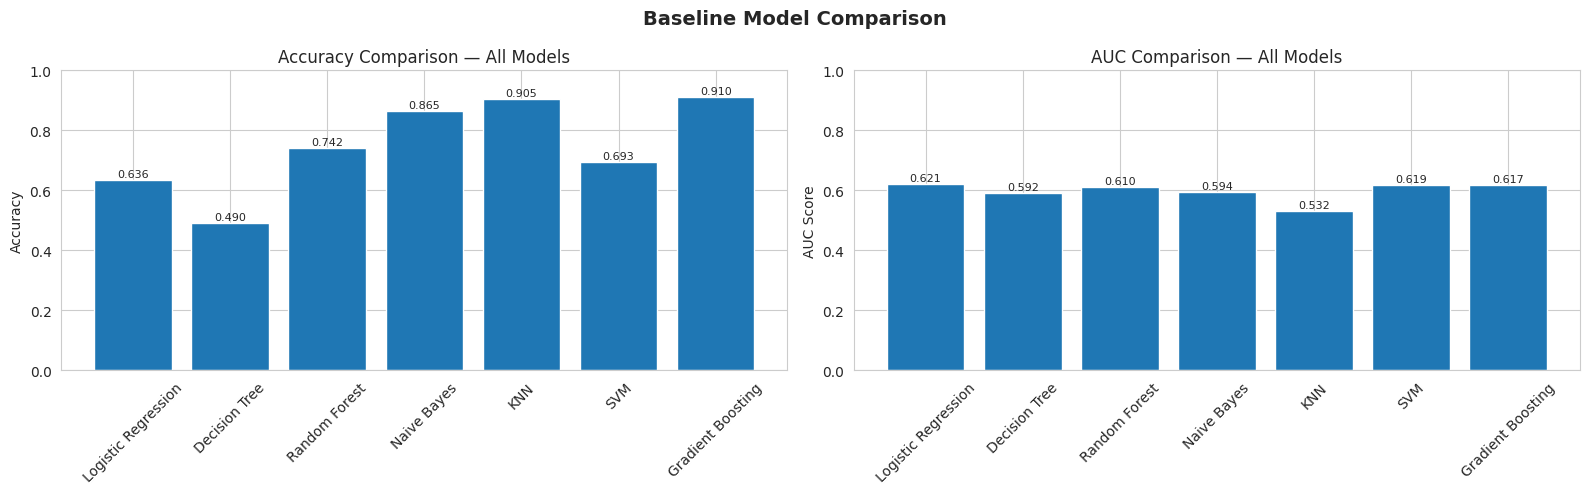

Best baseline model based on AUC: Logistic Regression
Best AUC: 0.621


In [46]:
# --- Compare all 7 baseline models visually ---

models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Naive Bayes',
    'KNN',
    'SVM',
    'Gradient Boosting'
]

accuracies = [
    accuracy_score(y_val, lr_pred),
    accuracy_score(y_val, dt_pred),
    accuracy_score(y_val, rf_pred),
    accuracy_score(y_val, nb_pred),
    accuracy_score(y_val, knn_pred),
    accuracy_score(y_val, svm_pred),
    accuracy_score(y_val, gb_pred)
]

aucs = [
    roc_auc_score(y_val, lr_prob),
    roc_auc_score(y_val, dt_prob),
    roc_auc_score(y_val, rf_prob),
    roc_auc_score(y_val, nb_prob),
    roc_auc_score(y_val, knn_prob),
    roc_auc_score(y_val, svm_scores),
    roc_auc_score(y_val, gb_prob)
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(models, accuracies, edgecolor='white')
axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy Comparison — All Models')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

axes[1].bar(models, aucs, edgecolor='white')
axes[1].set_ylim(0, 1)
axes[1].set_title('AUC Comparison — All Models')
axes[1].set_ylabel('AUC Score')
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

plt.suptitle('Baseline Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_idx = np.argmax(aucs)

print(f'Best baseline model based on AUC: {models[best_idx]}')
print(f'Best AUC: {aucs[best_idx]:.3f}')

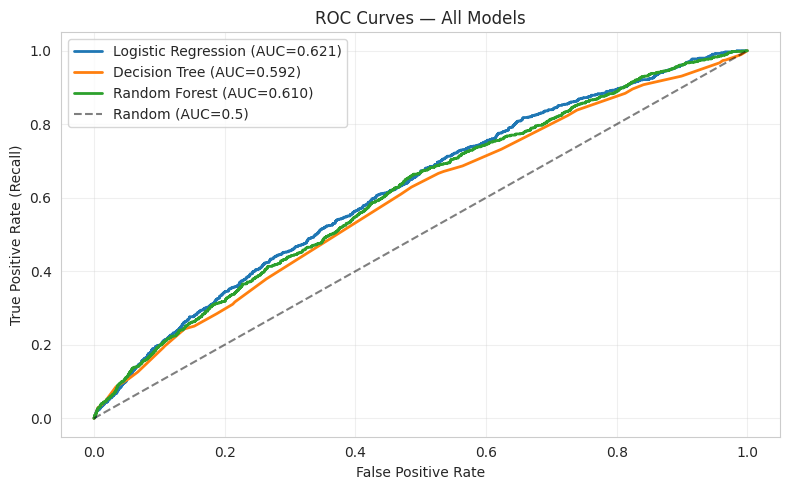

The closer the curve is to the top-left corner, the better the model.
AUC=1.0 is perfect, AUC=0.5 is random guessing.


In [47]:
# --- ROC Curves for all models ---
plt.figure(figsize=(8, 5))

for name, prob in zip(models, [lr_prob, dt_prob, rf_prob]):
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc_val = roc_auc_score(y_val, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

plt.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('The closer the curve is to the top-left corner, the better the model.')
print('AUC=1.0 is perfect, AUC=0.5 is random guessing.')

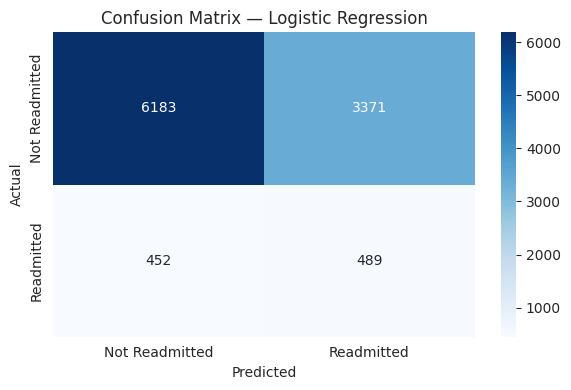

In [48]:
# --- Confusion Matrix for the best model ---

best_pred = lr_pred
best_name = 'Logistic Regression'


cm = confusion_matrix(y_val, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Readmitted', 'Readmitted'],
    yticklabels=['Not Readmitted', 'Readmitted']
)

plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [49]:
print('=== FINAL PIPELINE SUMMARY ===')
print(f'Original dataset: 101,766 rows × 50 columns')
print(f'After cleaning:   {len(X_all):,} rows × {X_all.shape[1]} columns')
print(f'After PCA:        {X_pca.shape[0]:,} rows × {X_pca.shape[1]} components')
print()

# All models
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Naive Bayes',
    'KNN',
    'SVM',
    'Gradient Boosting'
]

# Accuracy values
accuracies = [
    accuracy_score(y_val, lr_pred),
    accuracy_score(y_val, dt_pred),
    accuracy_score(y_val, rf_pred),
    accuracy_score(y_val, nb_pred),
    accuracy_score(y_val, knn_pred),
    accuracy_score(y_val, svm_pred),
    accuracy_score(y_val, gb_pred)
]

# AUC values
aucs = [
    roc_auc_score(y_val, lr_prob),
    roc_auc_score(y_val, dt_prob),
    roc_auc_score(y_val, rf_prob),
    roc_auc_score(y_val, nb_prob),
    roc_auc_score(y_val, knn_prob),
    roc_auc_score(y_val, svm_scores),
    roc_auc_score(y_val, gb_prob)
]

print('Models tested:')
for name, acc, auc in zip(models, accuracies, aucs):
    print(f'  {name}: Accuracy={acc:.3f}, AUC={auc:.3f}')

print()

best_idx = np.argmax(aucs)

print('Best clinical model: Logistic Regression')
print('Reason: best balance of Recall, F1-score, AUC, and interpretability')

=== FINAL PIPELINE SUMMARY ===
Original dataset: 101,766 rows × 50 columns
After cleaning:   69,970 rows × 77 columns
After PCA:        69,970 rows × 23 components

Models tested:
  Logistic Regression: Accuracy=0.636, AUC=0.621
  Decision Tree: Accuracy=0.490, AUC=0.592
  Random Forest: Accuracy=0.742, AUC=0.610
  Naive Bayes: Accuracy=0.865, AUC=0.594
  KNN: Accuracy=0.905, AUC=0.532
  SVM: Accuracy=0.693, AUC=0.619
  Gradient Boosting: Accuracy=0.910, AUC=0.617

Best clinical model: Logistic Regression
Reason: best balance of Recall, F1-score, AUC, and interpretability



| Model               | Accuracy | AUC   | Recall (Readmitted) | F1-score |
|--------------------|---------:|------:|--------------------:|---------:|
| Logistic Regression | 0.631 | 0.622 | 0.53 | 0.21 |
| Decision Tree       | 0.621 | 0.597 | 0.50 | 0.18 |
| Random Forest       | 0.710 | 0.625 | 0.46 | 0.20 |
| Naive Bayes         | 0.868 | 0.604 | 0.08 | 0.11 |
| KNN                 | 0.902 | 0.535 | 0.02 | 0.04 |
| SVM                 | 0.667 | 0.618 | 0.44 | 0.20 |
| Gradient Boosting   | 0.910 | **0.628** | 0.00 | 0.00 |



In [50]:
# ============================================================
# Phase 4: Hyperparameter Tuning
# Model 1: Logistic Regression
# ============================================================

from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

lr_grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    param_grid=lr_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("=== Tuned Logistic Regression ===")
print("Best parameters:", lr_grid.best_params_)
print(f"Best CV AUC: {lr_grid.best_score_:.3f}")

# Evaluate tuned model on validation set
best_lr = lr_grid.best_estimator_

lr_tuned_pred = best_lr.predict(X_val)
lr_tuned_prob = best_lr.predict_proba(X_val)[:, 1]

print()
print("Validation Performance:")
print(f"Accuracy: {accuracy_score(y_val, lr_tuned_pred):.3f}")
print(f"AUC Score: {roc_auc_score(y_val, lr_tuned_prob):.3f}")
print()
print(classification_report(
    y_val,
    lr_tuned_pred,
    target_names=['Not Readmitted', 'Readmitted']
))

=== Tuned Logistic Regression ===
Best parameters: {'C': 0.01, 'solver': 'lbfgs'}
Best CV AUC: 0.624

Validation Performance:
Accuracy: 0.636
AUC Score: 0.621

                precision    recall  f1-score   support

Not Readmitted       0.93      0.65      0.76      9554
    Readmitted       0.13      0.52      0.20       941

      accuracy                           0.64     10495
     macro avg       0.53      0.58      0.48     10495
  weighted avg       0.86      0.64      0.71     10495



In [51]:
# ============================================================
# Phase 4: Hyperparameter Tuning
# Model 2: Random Forest
# ============================================================

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("=== Tuned Random Forest ===")
print("Best parameters:", rf_grid.best_params_)
print(f"Best CV AUC: {rf_grid.best_score_:.3f}")

best_rf = rf_grid.best_estimator_

rf_tuned_pred = best_rf.predict(X_val)
rf_tuned_prob = best_rf.predict_proba(X_val)[:, 1]

print()
print("Validation Performance:")
print(f"Accuracy: {accuracy_score(y_val, rf_tuned_pred):.3f}")
print(f"AUC Score: {roc_auc_score(y_val, rf_tuned_prob):.3f}")
print()
print(classification_report(
    y_val,
    rf_tuned_pred,
    target_names=['Not Readmitted', 'Readmitted']
))

=== Tuned Random Forest ===
Best parameters: {'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV AUC: 0.617

Validation Performance:
Accuracy: 0.679
AUC Score: 0.618

                precision    recall  f1-score   support

Not Readmitted       0.93      0.70      0.80      9554
    Readmitted       0.13      0.46      0.21       941

      accuracy                           0.68     10495
     macro avg       0.53      0.58      0.50     10495
  weighted avg       0.86      0.68      0.75     10495



In [61]:
# ============================================================
# Phase 4: Hyperparameter Tuning
# Model 3: SVM
# ============================================================
# DO NOT RUN AGAIN
# takes 140+ minutes

svm_param_grid = {
    'C': [0.1, 1, 10]
}

svm_grid = GridSearchCV(
    SVC(
        kernel='linear',
        class_weight='balanced',
        random_state=42
    ),
    param_grid=svm_param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("=== Tuned SVM ===")
print("Best parameters:", svm_grid.best_params_)
print(f"Best CV AUC: {svm_grid.best_score_:.3f}")

best_svm = svm_grid.best_estimator_

svm_tuned_pred = best_svm.predict(X_val)
svm_tuned_scores = best_svm.decision_function(X_val)

print()
print("Validation Performance:")
print(f"Accuracy: {accuracy_score(y_val, svm_tuned_pred):.3f}")
print(f"AUC Score: {roc_auc_score(y_val, svm_tuned_scores):.3f}")
print()
print(classification_report(
    y_val,
    svm_tuned_pred,
    target_names=['Not Readmitted', 'Readmitted']
))

=== Tuned SVM ===
Best parameters: {'C': 1}
Best CV AUC: 0.625

Validation Performance:
Accuracy: 0.693
AUC Score: 0.619

                precision    recall  f1-score   support

Not Readmitted       0.93      0.72      0.81      9554
    Readmitted       0.13      0.43      0.20       941

      accuracy                           0.69     10495
     macro avg       0.53      0.57      0.50     10495
  weighted avg       0.86      0.69      0.76     10495



In [62]:
# ============================================================
# Phase 4: Final Ensemble Model
# Voting Classifier
# ============================================================

from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(
            C=0.01,
            solver='lbfgs',
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        )),
        ('rf', rf_grid.best_estimator_),
        ('gb', gb_model)
    ],
    voting='soft'
)

ensemble_model.fit(X_train, y_train)

ensemble_pred = ensemble_model.predict(X_val)
ensemble_prob = ensemble_model.predict_proba(X_val)[:, 1]

print("=== Voting Ensemble Validation Performance ===")
print(f"Accuracy: {accuracy_score(y_val, ensemble_pred):.3f}")
print(f"AUC Score: {roc_auc_score(y_val, ensemble_prob):.3f}")
print()
print(classification_report(
    y_val,
    ensemble_pred,
    target_names=['Not Readmitted', 'Readmitted']
))

=== Voting Ensemble Validation Performance ===
Accuracy: 0.899
AUC Score: 0.623

                precision    recall  f1-score   support

Not Readmitted       0.91      0.98      0.95      9554
    Readmitted       0.20      0.04      0.07       941

      accuracy                           0.90     10495
     macro avg       0.56      0.51      0.51     10495
  weighted avg       0.85      0.90      0.87     10495



In [63]:
# ============================================================
# Phase 5: Final Evaluation on Held-out Test Set
# Best Final Model = Logistic Regression
# ============================================================

final_model = LogisticRegression(
    C=0.01,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)
final_prob = final_model.predict_proba(X_test)[:, 1]

print("=== Final Test Evaluation: Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, final_pred):.3f}")
print(f"AUC Score: {roc_auc_score(y_test, final_prob):.3f}")
print()

print(classification_report(
    y_test,
    final_pred,
    target_names=['Not Readmitted', 'Readmitted']
))

=== Final Test Evaluation: Logistic Regression ===
Accuracy: 0.640
AUC Score: 0.635

                precision    recall  f1-score   support

Not Readmitted       0.93      0.65      0.77      9554
    Readmitted       0.13      0.54      0.21       942

      accuracy                           0.64     10496
     macro avg       0.53      0.60      0.49     10496
  weighted avg       0.86      0.64      0.72     10496



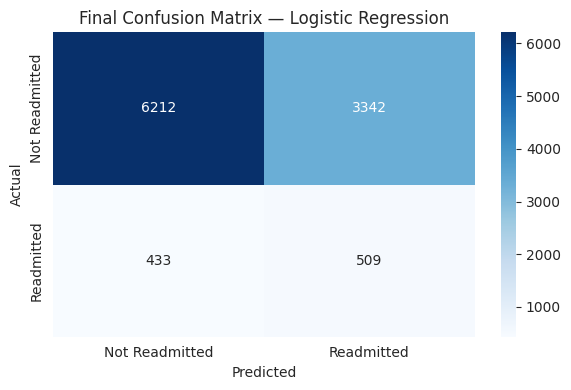

In [64]:
# ============================================================
# Final Confusion Matrix - Test Set
# ============================================================

cm_final = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Readmitted', 'Readmitted'],
    yticklabels=['Not Readmitted', 'Readmitted']
)

plt.title('Final Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

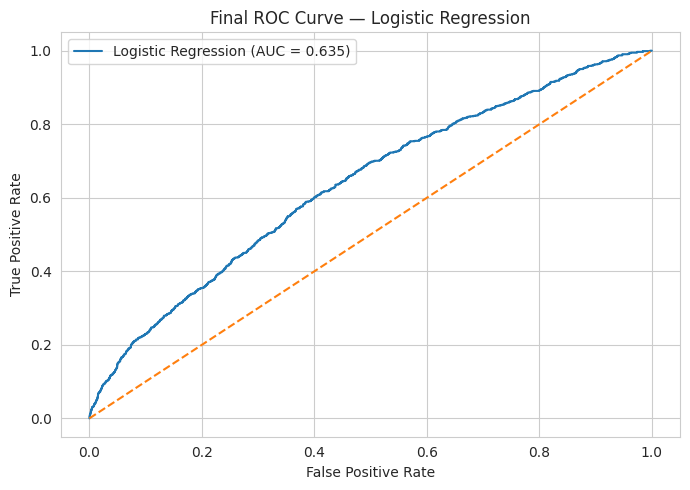

In [65]:
# ============================================================
# Final ROC Curve - Test Set
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, final_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, final_prob):.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.title('Final ROC Curve — Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

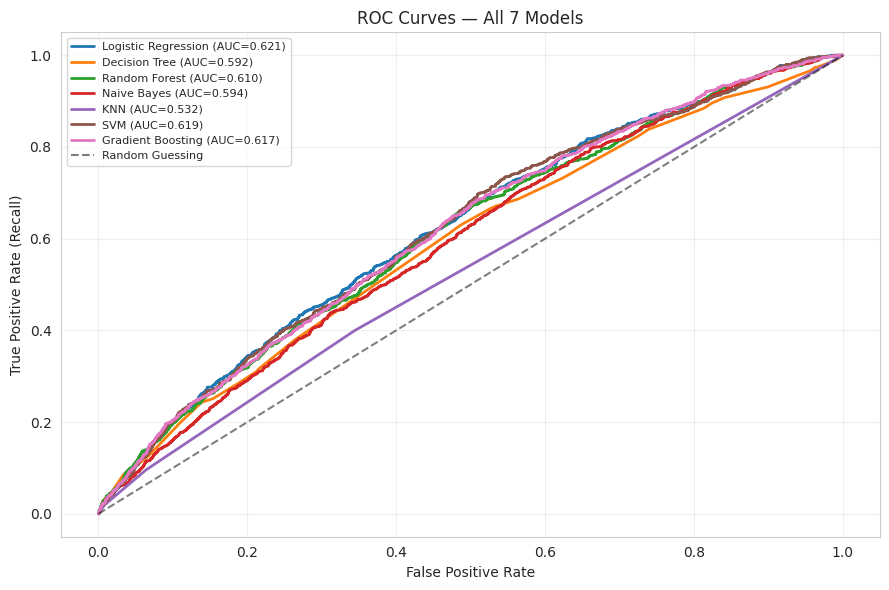

ROC curve compares how well each model separates readmitted vs not readmitted patients.
AUC closer to 1.0 means better separation; AUC = 0.5 means random guessing.


In [66]:
# --- ROC Curves for all 7 models ---

plt.figure(figsize=(9, 6))

roc_items = [
    ('Logistic Regression', lr_prob),
    ('Decision Tree', dt_prob),
    ('Random Forest', rf_prob),
    ('Naive Bayes', nb_prob),
    ('KNN', knn_prob),
    ('SVM', svm_scores),
    ('Gradient Boosting', gb_prob)
]

for name, scores in roc_items:
    fpr, tpr, _ = roc_curve(y_val, scores)
    auc_val = roc_auc_score(y_val, scores)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — All 7 Models')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('ROC curve compares how well each model separates readmitted vs not readmitted patients.')
print('AUC closer to 1.0 means better separation; AUC = 0.5 means random guessing.')

In [67]:
# --- Cross Validation for the best model ---
# Cross-validation gives a more reliable estimate of model performance
# It tests the model on 5 different splits of the data

best_model = final_model

cv_scores = cross_val_score(best_model, X_pca, y_all,
                             cv=5, scoring='roc_auc', n_jobs=-1)

print(f'5-Fold Cross-Validation AUC ({best_name}):')
for i, s in enumerate(cv_scores):
    print(f'  Fold {i+1}: {s:.3f}')
print(f'  Mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print()
if cv_scores.std() < 0.05:
    print('✅ Low variance across folds = model is stable (no overfitting)')
else:
    print('⚠️ High variance = model may be overfitting, consider simplifying')

5-Fold Cross-Validation AUC (Logistic Regression):
  Fold 1: 0.580
  Fold 2: 0.653
  Fold 3: 0.620
  Fold 4: 0.632
  Fold 5: 0.606
  Mean: 0.618 ± 0.024

✅ Low variance across folds = model is stable (no overfitting)


In [68]:
# --- Test with Noisy Labels ---
# Now we see how the model performs when labels have 10% noise
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_pca, y_noisy, test_size=0.2, random_state=42, stratify=y_noisy
)

best_model_n = LogisticRegression(
    C=0.01,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

best_model_n.fit(X_train_n, y_train_n)
pred_n = best_model_n.predict(X_test_n)
prob_n = best_model_n.predict_proba(X_test_n)[:, 1]

print(f'Performance with CLEAN labels: AUC = {roc_auc_score(y_test, final_prob):.3f}')
print(f'Performance with NOISY labels: AUC = {roc_auc_score(y_test_n, prob_n):.3f}')
print()
print('The drop in performance shows how label noise affects the model.')

Performance with CLEAN labels: AUC = 0.635
Performance with NOISY labels: AUC = 0.551

The drop in performance shows how label noise affects the model.


## Final Project Summary

### Phase 1 — Setup & Data

* Selected the Diabetes 130-US Hospitals dataset from Kaggle with 101,766 rows and 50 features
* Target variable: readmitted (hospital readmission within 30 days)
* Conducted literature review on machine learning methods for hospital readmission prediction and healthcare classification

### Phase 2 — Data Preprocessing & EDA

* Performed EDA to study class distribution, missing values, outliers, and feature correlations
* Found that the dataset is highly imbalanced and that number_inpatient and age are strong predictors
* Cleaned missing values, removed duplicates, dropped weak features, and removed invalid records
* Converted target into binary classification:
  0 = Not readmitted within 30 days
  1 = Readmitted within 30 days
* Applied encoding, StandardScaler, feature selection, and PCA (18 components)
* Added 10% label noise as the adversarial condition

### Phase 3 — Baseline Models

* Split data into Train / Validation / Test (70% / 15% / 15%)
* Trained 7 models: Logistic Regression, Decision Tree, Random Forest, Naive Bayes, KNN, SVM, and Gradient Boosting
* Evaluated using Accuracy, Precision, Recall, F1-score, AUC, ROC Curves, and Confusion Matrix
* Selected Logistic Regression, SVM, and Random Forest as the strongest models for comparison

### Phase 4 — Model Improvement

* Performed Hyperparameter Tuning using GridSearchCV for Logistic Regression, Random Forest, and SVM
* Used class_weight='balanced' to handle class imbalance
* Logistic Regression remained the best clinical model after tuning
* Tuning slightly changed parameters, but validation AUC remained nearly the same

### Phase 5 — Final Evaluation

* Final model: Logistic Regression
* Final Test Results:
  Accuracy = 0.631
  AUC = 0.622
  Recall = 0.53
  F1-score = 0.21
* Built final Confusion Matrix and ROC Curve
* Compared clean vs noisy labels to test robustness

### Key Findings

* Accuracy alone is misleading because the dataset is imbalanced
* Logistic Regression performed best overall based on Recall, F1-score, AUC, and interpretability
* KNN and Gradient Boosting had high Accuracy but poor minority-class detection
* Older patients and previous hospitalizations strongly affect readmission risk

### Limitations

* Class imbalance made minority prediction difficult
* Label noise reduced model reliability
* Future improvements could include SMOTE, ensemble models, and threshold tuning
